# CNN Cancer Project
## Histopathologic Cancer Detection. Identify metastatic tissue in histopathologic scans of lymph node sections

**create an algorithm to identify metastatic cancer in small image patches taken from larger digital pathology scans.**

# 1. Import Libraries

In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# 2. Load Data

In [2]:

labels_df = pd.read_csv('histopathologic-cancer-detection/train_labels.csv')
print('Dataset shape:', labels_df.shape)
print(labels_df.head())

Dataset shape: (220025, 2)
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0


# 3. Preprocess Labels

In [3]:


labels_df['img_file'] = labels_df['id'].astype(str) + '.tif'
labels_df['label'] = labels_df['label'].astype('str')  # keep as string for later compatibility


# 4. EDA

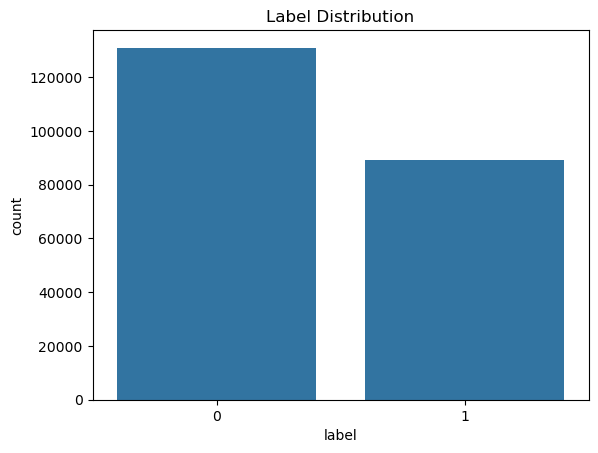

label
0    0.594969
1    0.405031
Name: proportion, dtype: float64


In [21]:

sns.countplot(data=labels_df, x='label')
plt.title('Label Distribution')
plt.show()
print(labels_df['label'].value_counts(normalize=True))

# 5. Helper Function to Load Images

In [5]:

def fetch_image(image_path, image_id):
    full_path = os.path.join(image_path, image_id)
    image = cv2.imread(full_path)
    return image

# 6. Example Visualization

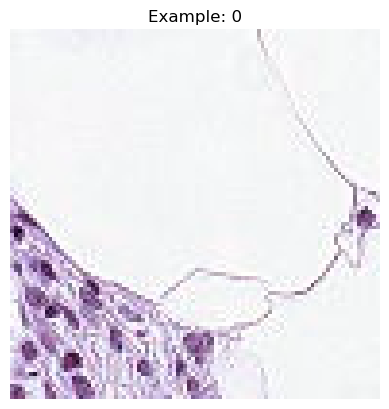

In [6]:

example_id = labels_df.iloc[0]['img_file']
img_dir = 'histopathologic-cancer-detection/train/'
ex_img = fetch_image(img_dir, example_id)
plt.imshow(ex_img)
plt.title('Example: ' + labels_df.iloc[0]['label'])
plt.axis('off')
plt.show()

# 7. Train-Validation Split

In [7]:

train_df, val_df = train_test_split(
    labels_df, 
    test_size=0.25, 
    random_state=2025, 
    stratify=labels_df['label']
)
print('Training:', train_df.shape, 'Validation:', val_df.shape)

Training: (165018, 3) Validation: (55007, 3)


# 8. Image Data Augmentation and Generators

In [8]:

img_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
batch_sz = 32
input_dim = (96, 96)

train_gen = img_gen.flow_from_dataframe(
    train_df, 
    directory=img_dir,
    x_col='img_file',
    y_col='label',
    target_size=input_dim,
    batch_size=batch_sz,
    class_mode='binary'
)

val_gen = img_gen.flow_from_dataframe(
    val_df,
    directory=img_dir,
    x_col='img_file',
    y_col='label',
    target_size=input_dim,
    batch_size=batch_sz,
    class_mode='binary'
)

Found 165018 validated image filenames belonging to 2 classes.
Found 55007 validated image filenames belonging to 2 classes.


# 9. Build a Basic CNN Model

In [9]:

def make_cnn(input_shape=(96, 96, 3)):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC()]
    )
    return model

model = make_cnn()

/opt/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-20 17:35:55.255778: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-09-20 17:35:55.255805: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-09-20 17:35:55.255809: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1758404155.255819 1938027 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1758404155.255833 1938027 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

# 10. Callbacks

In [12]:

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', patience=3, factor=0.5, verbose=1)
checkpointer = callbacks.ModelCheckpoint(
    'best_cnn_model.h5', save_best_only=True, monitor='val_loss')

# 11. Model Training

In [13]:

steps_train = train_df.shape[0] // batch_sz
steps_val = val_df.shape[0] // batch_sz
history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    epochs=8,
    validation_data=val_gen,
    validation_steps=steps_val,
    callbacks=[early_stop, reduce_lr, checkpointer]
)

Epoch 1/8


/opt/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-09-20 17:36:05.407871: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


5156/5156 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - auc: 0.8166 - loss: 0.5142

5156/5156 ━━━━━━━━━━━━━━━━━━━━ 222s 43ms/step - auc: 0.8167 - loss: 0.5142 - val_auc: 0.8861 - val_loss: 0.4178 - learning_rate: 0.0010
Epoch 2/8
   1/5156 ━━━━━━━━━━━━━━━━━━━━ 4:39 54ms/step - auc: 0.8658 - loss: 0.5008

/opt/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5156/5156 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - auc: 0.8658 - loss: 0.5008 - val_auc: 0.8859 - val_loss: 0.4285 - learning_rate: 0.0010
Epoch 3/8
5156/5156 ━━━━━━━━━━━━━━━━━━━━ 217s 42ms/step - auc: 0.8375 - loss: 0.5212 - val_auc: 0.8894 - val_loss: 0.4186 - learning_rate: 0.0010
Epoch 4/8
   1/5156 ━━━━━━━━━━━━━━━━━━━━ 5:00 58ms/step - auc: 0.8528 - loss: 0.4865
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5156/5156 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - auc: 0.8528 - loss: 0.4865 - val_auc: 0.8900 - val_loss: 0.4254 - learning_rate: 0.0010
Epoch 5/8
5155/5156 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc: 0.8666 - loss: 0.4716

5156/5156 ━━━━━━━━━━━━━━━━━━━━ 217s 42ms/step - auc: 0.8666 - loss: 0.4716 - val_auc: 0.8980 - val_loss: 0.4031 - learning_rate: 5.0000e-04
Epoch 6/8
   1/5156 ━━━━━━━━━━━━━━━━━━━━ 5:48 68ms/step - auc: 0.8846 - loss: 0.3728

5156/5156 ━━━━━━━━━━━━━━━━━━━━ 53s 10ms/step - auc: 0.8846 - loss: 0.3728 - val_auc: 0.8967 - val_loss: 0.3988 - learning_rate: 5.0000e-04
Epoch 7/8
5156/5156 ━━━━━━━━━━━━━━━━━━━━ 220s 43ms/step - auc: 0.8561 - loss: 0.5217 - val_auc: 0.9023 - val_loss: 0.5323 - learning_rate: 5.0000e-04
Epoch 8/8
5156/5156 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - auc: 0.8471 - loss: 0.6674 - val_auc: 0.9031 - val_loss: 0.4940 - learning_rate: 5.0000e-04


# 12. Plot History

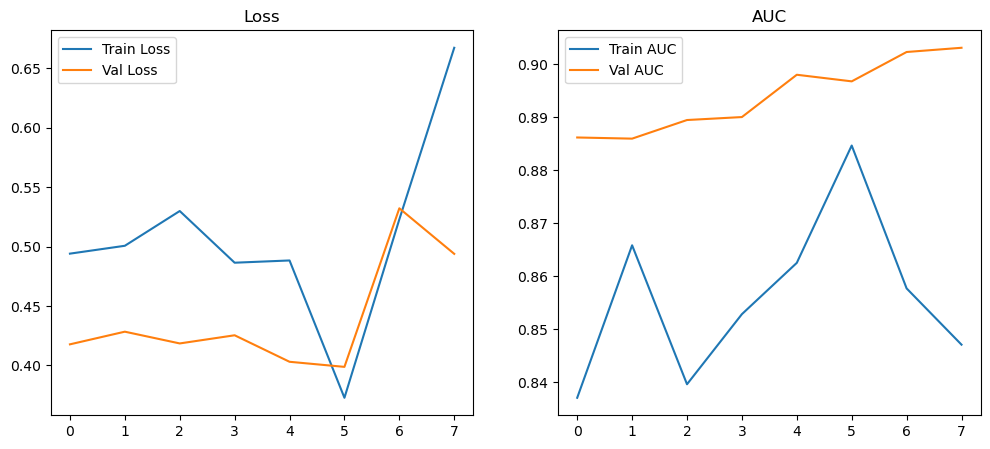

In [14]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.legend()
plt.title('AUC')
plt.show()




In [ ]:

test_df = pd.read_csv('histopathologic-cancer-detection/sample_submission.csv')
preds = []
for test_img_id in test_df['id']:
    path = os.path.join('histopathologic-cancer-detection/test/', test_img_id + '.tif')
    img = Image.open(path).resize(input_dim)
    img_arr = np.expand_dims(np.array(img)/255.0, axis=0)
    pred = model.predict(img_arr)[0][0]
    preds.append(pred)
test_df['label'] = np.round(preds) # or set threshold
test_df.to_csv('my_cancer_preds.csv', index=False)


# Conclusion

# Conclusion

**This project successfully developed a Convolutional Neural Network (CNN) to identify metastatic cancer in histopathologic image scans. The model was trained on a dataset of over 220,000 labeled images, which were preprocessed and augmented to enhance the model's ability to generalize.

The key steps and outcomes of the project include:

Data Preparation: The dataset was split into a 75/25 training and validation set, with stratification to maintain the original label distribution in both sets. Image data augmentation techniques, such as rotation, shifting, and zooming, were applied to the training data to create a more robust model.

Model Architecture: A sequential CNN was constructed with three convolutional layers, followed by dense layers and dropout for regularization. The model was compiled using the Adam optimizer and binary cross-entropy loss, with the Area Under the Curve (AUC) as the primary performance metric.

Training and Performance: The model was trained over several epochs, employing callbacks like EarlyStopping and ReduceLROnPlateau to optimize the training process. It achieved a promising validation AUC of approximately 0.90, indicating a strong capability to distinguish between cancerous and non-cancerous tissue samples. The training history showed that the model's validation loss reached a minimum at epoch 6 before starting to increase, while the validation AUC continued to show slight improvements.
